In [57]:
cultivar_batch_dict = {0: "Granny Smith", 1: "Granny Smith", 2: "Granny Smith", 3: "Granny Smith", 4: "Granny Smith", 5: "Joya", 6: "Envy", 7: "Granny Smith", 8: "Joya", 9: "Golden Delicious", 10: "Joya", 12:"Granny Smith", 13:"Golden Delicious", 23: "Golden Delicious", 32: "Granny Smith", 34: "Pink Lady"}

In [58]:
progression_dates = [3,	5,	7,	10,	14,	21,	28]

In [59]:
# treatment_1 = {3:"Early", 5:"Early", 7:"Early", 10:"Intermediate", 14:"Intermediate", 21:"Late"}
# treatment_2 = {3:"Early", 5:"Early", 7:"Early", 10:"Intermediate", 14:"Intermediate", 21:"Late"}
# treatment_3 = {3:"Early", 5:"Intermediate", 7:"Intermediate", 10:"Late"}
# treatment_4 = {3:"Early", 5:"Intermediate", 7:"Intermediate", 10:"Late"}
# treatment_5 = {3:"Early", 5:"Early", 7:"Early", 10:"Early", 14:"Early", 21:"Intermediate", 28: "Intermediate"}
# treatment_6 = {3:"Early", 5:"Early", 7:"Early", 10:"Intermediate", 14:"Intermediate", 21:"Late"}
# treatment_7 = {3:"Early", 5:"Early", 7:"Early", 10:"Early", 14:"Early", 21:"Intermediate", 28: "Intermediate"}

treatment_1 = {3:"Early", 5:"Early", 7:"Early", 10:"Intermediate", 14:"Intermediate", 21:"Late", 28:"Late"}
treatment_2 = {3:"Early", 5:"Early", 7:"Early", 10:"Intermediate", 14:"Intermediate", 21:"Late", 28:"Late"}
treatment_3 = {3:"Early", 5:"Intermediate", 7:"Intermediate", 10:"Late", 14:"Late", 21:"Late", 28:"Late"}
treatment_4 = {3:"Early", 5:"Intermediate", 7:"Intermediate", 10:"Late", 14:"Late", 21:"Late", 28:"Late"}
treatment_5 = {3:"Early", 5:"Early", 7:"Early", 10:"Early", 14:"Early", 21:"Intermediate", 28: "Intermediate"}
treatment_6 = {3:"Early", 5:"Early", 7:"Early", 10:"Intermediate", 14:"Intermediate", 21:"Late", 28:"Late"}
treatment_7 = {3:"Early", 5:"Early", 7:"Early", 10:"Early", 14:"Early", 21:"Intermediate", 28: "Intermediate"}
treatment_8 = {3:"Early", 5:"Intermediate", 7:"Intermediate"}


treatment_progressions = {
    1: treatment_1,
    2: treatment_2,
    3: treatment_3,
    4: treatment_4,
    5: treatment_5,
    6: treatment_6,
    7: treatment_7,
    8: treatment_8
}

def dpi_to_progression(treatment, dpi):
    """Map treatment/dpi pairs to progression labels."""
    try:
        if treatment is None or dpi is None:
            return None
        mapping = treatment_progressions.get(int(treatment))
        if mapping is None:
            return None
        return mapping.get(int(dpi))
    except Exception:
        return None


In [60]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import random


def dataset_membership_df(dataset_dir: str | Path) -> pd.DataFrame:
    """Return a dataframe with sample_name plus train/val/test indicator columns."""
    dataset_path = Path(dataset_dir)
    if not any((dataset_path / s).exists() for s in ("train", "val", "test")):
        nested = dataset_path / "dataset"
        if nested.exists():
            dataset_path = nested

    rows: dict[str, dict[str, int]] = {}
    for split in ("train", "val", "test"):
        split_path = dataset_path / split
        if not split_path.exists():
            continue
        for file in split_path.rglob("*"):
            if file.is_file():
                name = file.name
                rows.setdefault(name, {"sample_name": name, "train": 0, "val": 0, "test": 0})
                rows[name][split] = 1

    if not rows:
        return pd.DataFrame(columns=["sample_name", "train", "val", "test"])
    return pd.DataFrame(rows.values()).sort_values("sample_name").reset_index(drop=True)


In [61]:
df = dataset_membership_df("/mnt/slowdisk/public/HIPPA/multiclass_classification")

In [62]:
df.head()
df.to_csv("train_val_test.csv")
len(df)

14388

In [63]:
df[df["val"]==1].head()

,sample_name,train,val,test
144,RGB_04006_241021_000.jpg,0,1,0
145,RGB_04006_241021_090.jpg,0,1,0
146,RGB_04006_241021_180.jpg,0,1,0
147,RGB_04006_241021_270.jpg,0,1,0
148,RGB_04006_241023_000.jpg,0,1,0


In [64]:
def dataset_metadata_df(dataset_dir: str | Path) -> pd.DataFrame:
    """Return dataframe with sample metadata plus train/val/test indicators."""
    dataset_path = Path(dataset_dir)
    if not any((dataset_path / s).exists() for s in ("train", "val", "test")):
        nested = dataset_path / "dataset"
        if nested.exists():
            dataset_path = nested

    def _parse(name: str):
        parts = name.split("_")
        modality = parts[0] if parts else None
        segment = parts[1] if len(parts) > 1 else None
        batch = int(segment[:2]) if segment and segment[:2].isdigit() else None
        treatment = int(segment[2]) if segment and len(segment) > 2 and segment[2].isdigit() else None
        apple_id = segment[3:] if segment and len(segment) > 3 else segment
        date = parts[2] if len(parts) > 2 else None
        angle = parts[3].split(".")[0] if len(parts) > 3 else None
        cultivar = cultivar_batch_dict.get(batch) if 'cultivar_batch_dict' in globals() else None
        return modality, apple_id, batch, treatment, cultivar, date, angle

    rows: dict[str, dict[str, object]] = {}
    for split in ("train", "val", "test"):
        split_path = dataset_path / split
        if not split_path.exists():
            continue
        for file in split_path.rglob("*"):
            if file.is_file():
                name = file.name
                modality, apple_id, batch, treatment, cultivar, date, angle = _parse(name)
                rows.setdefault(
                    name,
                    {
                        "sample_name": name,
                        "apple_id": apple_id,
                        "modality": modality,
                        "batch": batch,
                        "cultivar": cultivar,
                        "treatment": treatment,
                        "date": date,
                        "angle": angle,
                        "train": 0,
                        "val": 0,
                        "test": 0,
                    },
                )
                rows[name][split] = 1

    if not rows:
        return pd.DataFrame(columns=["sample_name", "apple_id", "modality", "batch", "cultivar", "treatment", "date", "dpi", "progression", "angle", "train", "val", "test"])

    df = pd.DataFrame(rows.values())
    df["date_dt"] = pd.to_datetime(df["date"], format="%y%m%d", errors="coerce")

    def date_to_dpi_map(grp: pd.DataFrame) -> dict:
        unique_dates = grp["date_dt"].dropna().drop_duplicates().sort_values().reset_index(drop=True)
        mapping = {}
        for idx, d in enumerate(unique_dates):
            if idx < len(progression_dates):
                mapping[d.strftime("%y%m%d")] = progression_dates[idx]
        return mapping

    df["dpi"] = df.groupby("batch", dropna=False, group_keys=False).apply(
        lambda g: g["date"].map(date_to_dpi_map(g))
    )
    df.drop(columns=["date_dt"], inplace=True)
    df["progression"] = [dpi_to_progression(t, d) for t, d in zip(df["treatment"], df["dpi"])]
    return df[["sample_name", "apple_id", "modality", "batch", "cultivar", "treatment", "date", "dpi", "progression", "angle", "train", "val", "test"]].sort_values("sample_name").reset_index(drop=True)


In [65]:
df_splitted = dataset_metadata_df("/mnt/slowdisk/public/HIPPA/multiclass_classification")
mask = (df_splitted["batch"] == 34) & (df_splitted["dpi"] == 14)
df_splitted.loc[mask, "dpi"] = 21
df_splitted


/tmp/ipykernel_82408/2670761978.py:62: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df["dpi"] = df.groupby("batch", dropna=False, group_keys=False).apply(


,sample_name,apple_id,modality,batch,cultivar,treatment,date,dpi,progression,angle,train,val,test
0,RGB_04000_241021_000.jpg,00,RGB,4,Granny Smith,0,241021,3,None,000,1,0,0
1,RGB_04000_241021_090.jpg,00,RGB,4,Granny Smith,0,241021,3,None,090,1,0,0
2,RGB_04000_241021_180.jpg,00,RGB,4,Granny Smith,0,241021,3,None,180,1,0,0
3,RGB_04000_241021_270.jpg,00,RGB,4,Granny Smith,0,241021,3,None,270,1,0,0
4,RGB_04000_241023_000.jpg,00,RGB,4,Granny Smith,0,241023,5,None,000,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14383,RGB_34823_251203_270.jpg,23,RGB,34,Pink Lady,8,251203,5,Intermediate,270,0,0,1
14384,RGB_34823_251205_000.jpg,23,RGB,34,Pink Lady,8,251205,7,Intermediate,000,0,0,1
14385,RGB_34823_251205_090.jpg,23,RGB,34,Pink Lady,8,251205,7,Intermediate,090,0,0,1
14386,RGB_34823_251205_180.jpg,23,RGB,34,Pink Lady,8,251205,7,Intermediate,180,0,0,1


In [66]:
df_csv_path = df_splitted[["sample_name", "cultivar", "progression"]]
df_csv_path.to_csv("/home/hemamgholizadeh/hippa-rgb/data/meta_data.csv")

In [67]:
df_splitted[(df_splitted["treatment"] == 2) & (df_splitted["progression"] == None)].head(10)

,sample_name,apple_id,modality,batch,cultivar,treatment,date,dpi,progression,angle,train,val,test


In [68]:
def check_split_leakage(meta_df: pd.DataFrame | None = None, dataset_dir: str | Path | None = None) -> pd.DataFrame:
    """Detect apples (batch+treatment+apple_id) that land in more than one split.

    Pass either a precomputed dataframe from dataset_metadata_df or a dataset_dir to load one.
    Returns a dataframe of violations with the splits each apple touches.
    """
    if meta_df is None:
        if dataset_dir is None:
            raise ValueError("Provide either meta_df or dataset_dir")
        meta_df = dataset_metadata_df(dataset_dir)
    if meta_df.empty:
        return pd.DataFrame(columns=["batch", "treatment", "apple_id", "splits", "file_count"])

    def splits_present(group: pd.DataFrame) -> list[str]:
        return [s for s in ("train", "val", "test") if group[s].any()]
    violations = []
    for (batch, treatment, apple_id), group in meta_df.groupby(["batch", "treatment", "apple_id"], dropna=False):
        splits = splits_present(group)
        if len(splits) > 1:
            violations.append(
                {
                    "batch": batch,
                    "treatment": treatment,
                    "apple_id": apple_id,
                    "splits": splits,
                    "file_count": len(group),
                }
            )

    if not violations:
        print("No split leakage detected: each apple appears in a single split across train/val/test.")
        return pd.DataFrame(columns=["batch", "treatment", "apple_id", "splits", "file_count"])
    print(f"Found {len(violations)} apples spanning multiple splits.")
    return pd.DataFrame(violations).sort_values(["batch", "treatment", "apple_id"]).reset_index(drop=True)


In [69]:
df_splitted = dataset_metadata_df("/mnt/slowdisk/public/HIPPA/multiclass_classification")  # adjust as needed
mask = (df_splitted["batch"] == 34) & (df_splitted["dpi"] == 14)
df_splitted.loc[mask, "dpi"] = 21
leaks = check_split_leakage(meta_df=df_splitted)
leaks


No split leakage detected: each apple appears in a single split across train/val/test.


/tmp/ipykernel_82408/2670761978.py:62: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df["dpi"] = df.groupby("batch", dropna=False, group_keys=False).apply(


,batch,treatment,apple_id,splits,file_count


In [70]:
def summarize_splits(meta_df: pd.DataFrame) -> dict:
    """Return split totals and split-by-treatment totals from metadata dataframe."""
    if meta_df.empty:
        return {"split_counts": {}, "treatment_split_counts": pd.DataFrame()}

    split_counts = {split: int(meta_df[split].sum()) for split in ("train", "val", "test")}
    treatment_split_counts = (
        meta_df.groupby("treatment")[['train', 'val', 'test']].sum().astype(int).sort_index()
    )
    return {"split_counts": split_counts, "treatment_split_counts": treatment_split_counts}



summary = summarize_splits(df_splitted)
summary["split_counts"], summary["treatment_split_counts"]


({'train': 10072, 'val': 2236, 'test': 2080},
            train  val  test
 treatment                  
 0           3028  684   624
 1           1772  376   380
 2           1012  200   180
 3            612  136   116
 4            600  132   132
 5            448  112   112
 6            448   84    84
 7           1048  240   224
 8           1104  272   228)

In [71]:
def random_apple_progression(meta_df: pd.DataFrame, seed: int = 123) -> pd.DataFrame:
    """Pick a random apple/treatment/angle and show its samples across dates."""
    if meta_df.empty:
        return pd.DataFrame()
    rng = random.Random(seed)
    key_cols = ["apple_id", "treatment", "angle"]
    groups = list(meta_df.groupby(key_cols, dropna=False))
    (apple_id, treatment, angle), group = rng.choice(groups)
    out = group.sort_values("date")[
        [
            "sample_name", "apple_id", "treatment", "angle", "date", "dpi", "progression", "train", "val", "test"
        ]
    ].reset_index(drop=True)
    print(f"Selected apple_id={apple_id}, treatment={treatment}, angle={angle} across {len(out)} samples")
    return out


# Example usage:
random_apple_progression(df_splitted)


Selected apple_id=01, treatment=4, angle=090 across 9 samples


,sample_name,apple_id,treatment,angle,date,dpi,progression,train,val,test
0,RGB_07401_241202_090.jpg,01,4,090,241202,3,Early,1,0,0
1,RGB_08401_241202_090.jpg,01,4,090,241202,3,Early,1,0,0
2,RGB_07401_241204_090.jpg,01,4,090,241204,5,Intermediate,1,0,0
3,RGB_08401_241204_090.jpg,01,4,090,241204,5,Intermediate,1,0,0
4,RGB_07401_241206_090.jpg,01,4,090,241206,7,Intermediate,1,0,0
5,RGB_08401_241206_090.jpg,01,4,090,241206,7,Intermediate,1,0,0
6,RGB_13401_250505_090.jpg,01,4,090,250505,3,Early,1,0,0
7,RGB_13401_250507_090.jpg,01,4,090,250507,5,Intermediate,1,0,0
8,RGB_13401_250509_090.jpg,01,4,090,250509,7,Intermediate,1,0,0


In [72]:
df_splitted[(df_splitted["treatment"] == 3) & (df_splitted["angle"] == "000")].head(5)

,sample_name,apple_id,modality,batch,cultivar,treatment,date,dpi,progression,angle,train,val,test
5040,RGB_10300_250217_000.jpg,00,RGB,10,Joya,3,250217,3,Early,000,1,0,0
5044,RGB_10300_250219_000.jpg,00,RGB,10,Joya,3,250219,5,Intermediate,000,1,0,0
5048,RGB_10300_250224_000.jpg,00,RGB,10,Joya,3,250224,10,Late,000,1,0,0
5052,RGB_10300_250228_000.jpg,00,RGB,10,Joya,3,250228,14,Late,000,1,0,0
5056,RGB_10300_250307_000.jpg,00,RGB,10,Joya,3,250307,21,Late,000,1,0,0


In [73]:
PROJ_NAME = "/mnt/slowdisk/public/HIPPA"
TASK = "multiclass_classification"
DATA_DIR = "/mnt/slowdisk/public/HIPPA"

In [74]:
def batch_treatment_progression(meta_df: pd.DataFrame) -> pd.DataFrame:
    """Return progression order per (batch, treatment) where earliest date=1, next=2, etc."""
    if meta_df.empty:
        return pd.DataFrame()
    df = meta_df.dropna(subset=["batch", "treatment", "date"]).copy()
    df["date_dt"] = pd.to_datetime(df["date"], format="%y%m%d", errors="coerce")
    df = df.dropna(subset=["date_dt"])
    if df.empty:
        return pd.DataFrame()

    records = []
    for (batch, treatment), grp in df.groupby(["batch", "treatment"], dropna=False):
        dates = grp["date_dt"].drop_duplicates().sort_values().reset_index(drop=True)
        cultivar = grp.get("cultivar")
        cultivar_name = cultivar.iloc[0] if cultivar is not None and not cultivar.dropna().empty else None
        for idx, d in enumerate(dates, start=1):
            dpi_values = grp.loc[grp["date_dt"] == d, "dpi"].dropna().unique() if "dpi" in grp else []
            dpi = int(dpi_values[0]) if len(dpi_values) > 0 else (progression_dates[idx - 1] if idx - 1 < len(progression_dates) else None)
            stage = dpi_to_progression(treatment, dpi)
            records.append({"batch": batch, "cultivar": cultivar_name, "treatment": treatment, "date": d.strftime("%y%m%d"), "dpi": dpi, "progression_stage": stage, "progression": idx, "samples": int(grp[grp["date_dt"] == d].shape[0])})
    if not records:
        return pd.DataFrame()
    return pd.DataFrame(records).sort_values(["batch", "treatment", "progression"]).reset_index(drop=True)


# Example usage:
progression_df = batch_treatment_progression(df_splitted)
progression_df


,batch,cultivar,treatment,date,dpi,progression_stage,progression,samples
0,4,Granny Smith,0,241021,3,None,1,96
1,4,Granny Smith,0,241023,5,None,2,96
2,4,Granny Smith,0,241025,7,None,3,96
3,4,Granny Smith,0,241028,10,None,4,96
4,4,Granny Smith,0,241031,14,None,5,96
...,...,...,...,...,...,...,...,...
148,34,Pink Lady,7,251205,7,Early,3,96
149,34,Pink Lady,7,251219,21,Intermediate,4,96
150,34,Pink Lady,8,251201,3,Early,1,96
151,34,Pink Lady,8,251203,5,Intermediate,2,96


In [75]:
progression_df[progression_df["treatment"] == 2].head(10)

,batch,cultivar,treatment,date,dpi,progression_stage,progression,samples
32,8,Joya,2,241202,3,Early,1,96
33,8,Joya,2,241204,5,Early,2,96
34,8,Joya,2,241206,7,Early,3,96
35,8,Joya,2,241209,10,Intermediate,4,96
36,8,Joya,2,241213,14,Intermediate,5,96
47,10,Joya,2,250217,3,Early,1,88
48,10,Joya,2,250219,5,Early,2,88
49,10,Joya,2,250221,7,Early,3,88
50,10,Joya,2,250224,10,Intermediate,4,88
51,10,Joya,2,250228,14,Intermediate,5,88


In [76]:
progression_df["dpi"].unique()

array([ 3,  5,  7, 10, 14, 21, 28])

In [77]:
progression_df[(progression_df["treatment"] == 2) ].head(10)

,batch,cultivar,treatment,date,dpi,progression_stage,progression,samples
32,8,Joya,2,241202,3,Early,1,96
33,8,Joya,2,241204,5,Early,2,96
34,8,Joya,2,241206,7,Early,3,96
35,8,Joya,2,241209,10,Intermediate,4,96
36,8,Joya,2,241213,14,Intermediate,5,96
47,10,Joya,2,250217,3,Early,1,88
48,10,Joya,2,250219,5,Early,2,88
49,10,Joya,2,250221,7,Early,3,88
50,10,Joya,2,250224,10,Intermediate,4,88
51,10,Joya,2,250228,14,Intermediate,5,88


In [78]:
def summarize_progression(progression_df: pd.DataFrame) -> pd.DataFrame:
    """Summarize progression counts per treatment: how many batches have N rounds."""
    if progression_df.empty:
        return pd.DataFrame()
    summary = progression_df.groupby(['treatment', 'progression']).size().unstack(fill_value=0)
    summary = summary.sort_index().astype(int)
    summary.index.name = 'treatment'
    return summary

# Example usage:
progression_df = batch_treatment_progression(df_splitted)
summarize_progression(progression_df)


progression,1,2,3,4,5,6,7
treatment,,,,,,,
0,9,9,9,7,7,4,1
1,5,5,5,5,4,3,0
2,3,3,3,3,2,1,0
3,2,2,2,2,1,0,0
4,3,3,3,0,0,0,0
5,1,1,1,1,1,1,1
6,1,1,1,1,1,1,1
7,3,3,3,3,2,2,0
8,6,5,5,1,0,0,0


In [79]:
def cultivar_treatment_progression(meta_df: pd.DataFrame) -> pd.DataFrame:
    """Return progression order per (cultivar, treatment) where earliest date=1."""
    if meta_df.empty:
        return pd.DataFrame()
    df = meta_df.dropna(subset=["cultivar", "treatment", "date"]).copy()
    df["date_dt"] = pd.to_datetime(df["date"], format="%y%m%d", errors="coerce")
    df = df.dropna(subset=["date_dt"])
    if df.empty:
        return pd.DataFrame()

    records = []
    for (cultivar, treatment), grp in df.groupby(["cultivar", "treatment"], dropna=False):
        dates = grp["date_dt"].drop_duplicates().sort_values().reset_index(drop=True)
        batches = sorted(grp["batch"].dropna().unique()) if "batch" in grp else []
        for idx, d in enumerate(dates, start=1):
            dpi_values = grp.loc[grp["date_dt"] == d, "dpi"].dropna().unique() if "dpi" in grp else []
            dpi = int(dpi_values[0]) if len(dpi_values) > 0 else (progression_dates[idx - 1] if idx - 1 < len(progression_dates) else None)
            stage = dpi_to_progression(treatment, dpi)
            records.append({
                "cultivar": cultivar,
                "treatment": treatment,
                "date": d.strftime("%y%m%d"),
                "dpi": dpi,
                "progression_stage": stage,
                "progression": idx,
                "samples": int(grp[grp["date_dt"] == d].shape[0]),
                "batches": batches,
            })
    if not records:
        return pd.DataFrame()
    return pd.DataFrame(records).sort_values(["cultivar", "treatment", "progression"]).reset_index(drop=True)


# Example usage:
cultivar_progression_df = cultivar_treatment_progression(df_splitted)
cultivar_progression_df


,cultivar,treatment,date,dpi,progression_stage,progression,samples,batches
0,Golden Delicious,0,250505,3,None,1,96,"[13, 23]"
1,Golden Delicious,0,250507,5,None,2,92,"[13, 23]"
2,Golden Delicious,0,250509,7,None,3,92,"[13, 23]"
3,Golden Delicious,0,251022,3,None,4,96,"[13, 23]"
4,Golden Delicious,0,251024,5,None,5,96,"[13, 23]"
...,...,...,...,...,...,...,...,...
148,Pink Lady,7,251205,7,Early,3,96,[34]
149,Pink Lady,7,251219,21,Intermediate,4,96,[34]
150,Pink Lady,8,251201,3,Early,1,96,[34]
151,Pink Lady,8,251203,5,Intermediate,2,96,[34]


In [80]:
def summarize_cultivar_progression(progression_df: pd.DataFrame) -> pd.DataFrame:
    """Summarize progression counts with explicit treatment labels per cultivar."""
    if progression_df.empty:
        return pd.DataFrame()
    summary = progression_df.groupby(["cultivar", "treatment", "progression"]).size().reset_index(name="count")
    summary["treatment_label"] = summary["treatment"].apply(lambda t: f"treatment {t}")
    pivot = summary.pivot_table(
        index=["cultivar", "treatment", "treatment_label"],
        columns="progression",
        values="count",
        fill_value=0,
    ).sort_index()
    pivot.columns = [f"progression_{int(c)}" for c in pivot.columns]
    return pivot.astype(int)


# Example usage (two cultivars expected):
cultivar_progression_df = cultivar_treatment_progression(df_splitted)
summarize_cultivar_progression(cultivar_progression_df)


progression_1  progression_2  \
cultivar         treatment treatment_label                                 
Golden Delicious 0         treatment 0                  1              1   
                 1         treatment 1                  1              1   
                 3         treatment 3                  1              1   
                 4         treatment 4                  1              1   
                 8         treatment 8                  1              1   
Granny Smith     0         treatment 0                  1              1   
                 1         treatment 1                  1              1   
                 2         treatment 2                  1              1   
                 4         treatment 4                  1              1   
                 7         treatment 7                  1              1   
                 8         treatment 8                  1              1   
Joya             0         treatment 0                  1              1   
                 1         treatment 1                  1              1   
                 2         treatment 2                  1              1   
                 3         treatment 3                  1              1   
                 4         treatment 4                  1              1   
                 5         treatment 5                  1              1   
                 6         treatment 6                  1              1   
                 7         treatment 7                  1              1   
                 8         treatment 8                  1              1   
Pink Lady        0         treatment 0                  1              1   
                 1         treatment 1                  1              1   
                 7         treatment 7                  1              1   
                 8         treatment 8                  1              1   

                                            progression_3  progression_4  \
cultivar         treatment treatment_label                                 
Golden Delicious 0         treatment 0                  1              1   
                 1         treatment 1                  1              1   
                 3         treatment 3                  1              1   
                 4         treatment 4                  1              0   
                 8         treatment 8                  1              1   
Granny Smith     0         treatment 0                  1              1   
                 1         treatment 1                  1              1   
                 2         treatment 2                  1              1   
                 4         treatment 4                  1              0   
                 7         treatment 7                  1              1   
                 8         treatment 8                  1              1   
Joya             0         treatment 0                  1              1   
                 1         treatment 1                  1              1   
                 2         treatment 2                  1              1   
                 3         treatment 3                  1              1   
                 4         treatment 4                  1              0   
                 5         treatment 5                  1              1   
                 6         treatment 6                  1              1   
                 7         treatment 7                  1              1   
                 8         treatment 8                  1              1   
Pink Lady        0         treatment 0                  1              1   
                 1         treatment 1                  1              1   
                 7         treatment 7                  1              1   
                 8         treatment 8                  1              0   

                                            progression_5  progression_6  \
cultivar      

In [81]:
def plot_apple_progression_images(meta_df: pd.DataFrame, dataset_dir: str | Path, treatments=None, seed: int = 42, show: bool = True):
    """Show one apple (batch+apple_id+angle) per treatment, sorted by treatment."""
    if meta_df.empty:
        print("No data to plot.")
        return None
    dataset_path = Path(dataset_dir)
    if not any((dataset_path / s).exists() for s in ("train", "val", "test")) and (dataset_path / "dataset").exists():
        dataset_path = dataset_path / "dataset"

    treatments = sorted(treatments) if treatments is not None else sorted(meta_df["treatment"].dropna().unique())
    rng = random.Random(seed)

    selections = []
    for t in treatments:
        grp = meta_df[meta_df["treatment"] == t]
        if grp.empty:
            continue
        candidates = []
        for (batch, aid, ang), g in grp.groupby(["batch", "apple_id", "angle"], dropna=False):
            candidates.append((len(g), g["date"].nunique(), rng.random(), batch, aid, ang, g))
        if not candidates:
            continue
        candidates.sort(reverse=True, key=lambda x: (x[0], x[1], x[2]))
        _, _, _, batch, aid, ang, chosen = candidates[0]
        subset = chosen.sort_values("date").copy()
        subset["split"] = subset[["train", "val", "test"]].idxmax(axis=1)
        subset["_key"] = t
        selections.append(subset)

    if not selections:
        print("No matching samples to plot.")
        return None

    max_cols = max(len(s) for s in selections)
    rows = len(selections)
    fig, axes = plt.subplots(rows, max_cols, figsize=(3 * max_cols, 3 * rows))
    if rows == 1:
        axes = [axes]
    for row_idx, subset in enumerate(sorted(selections, key=lambda s: s.iloc[0]["_key"])):
        for col_idx in range(max_cols):
            ax = axes[row_idx][col_idx] if rows > 1 else axes[col_idx]
            if col_idx >= len(subset):
                ax.axis("off")
                continue
            row = subset.iloc[col_idx]
            split = row["split"]
            class_dir = dataset_path / split / f"class_{int(row['treatment'])}"
            candidate = class_dir / row["sample_name"]
            if candidate.exists():
                img = plt.imread(candidate)
                ax.imshow(img)
            else:
                ax.text(0.5, 0.5, "Missing\nimage", ha="center", va="center")
            label = f"batch {int(row['batch'])} | treat {int(row['treatment'])} | apple {row['apple_id']} | angle {row['angle']}"
            ax.set_title(f"{label}\n{row['sample_name']} • {row['date']} ({split})", fontsize=8)
            ax.axis("off")
    fig.suptitle("One apple progression per treatment")
    fig.tight_layout()
    if show:
        plt.show()
        return None
    return fig


# Example usage:
# plot_apple_progression_images(df_splitted, Path(PROJ_NAME)/TASK, treatments=range(9))

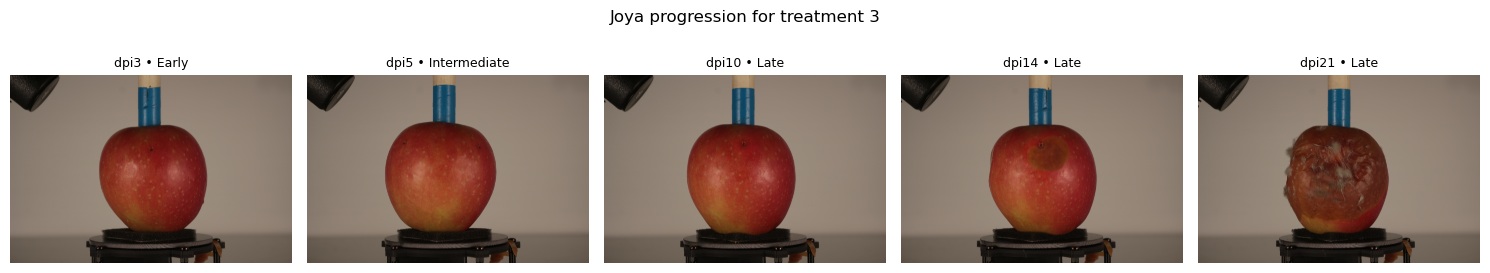

In [82]:
from pathlib import Path
import random
import pandas as pd
import matplotlib.pyplot as plt
from bisect import bisect_right


def plot_selected_treatment_progression(
    meta_df: pd.DataFrame,
    dataset_dir: str | Path,
    treatment: int | float | str,
    seed: int | None = 42,
    show: bool = True,
):
    """Show one apple progression for a chosen treatment (title: '<Cultivar> progression for treatment X'; per-image: dpi + stage)."""
    if meta_df is None or meta_df.empty:
        print("No data to plot.")
        return None
    if treatment is None:
        print("Please provide a treatment id to plot.")
        return None

    try:
        typed_treatment = meta_df["treatment"].dtype.type(treatment)
    except Exception:
        typed_treatment = treatment

    dataset_path = Path(dataset_dir)
    if not any((dataset_path / s).exists() for s in ("train", "val", "test")) and (dataset_path / "dataset").exists():
        dataset_path = dataset_path / "dataset"

    grp = meta_df[meta_df["treatment"] == typed_treatment]
    if grp.empty:
        print(f"No samples found for treatment {typed_treatment}.")
        return None

    rng = random.Random(seed)
    candidates = []
    for (batch, aid, ang), g in grp.groupby(["batch", "apple_id", "angle"], dropna=False):
        candidates.append((len(g), g["date"].nunique(), rng.random(), batch, aid, ang, g))
    if not candidates:
        print(f"No samples found for treatment {typed_treatment}.")
        return None

    candidates.sort(reverse=True, key=lambda x: (x[0], x[1], x[2]))
    chosen = candidates[0][-1].sort_values("date").copy()
    chosen["split"] = chosen[["train", "val", "test"]].idxmax(axis=1)

    # --- stage lookup (dpi -> stage) ---
    def stage_from_mapping(dpi: int, mapping: dict[int, str]) -> str | None:
        ks = sorted(mapping)
        if not ks:
            return None
        if dpi < ks[0]:
            return mapping[ks[0]]  # back-fill
        return mapping[ks[bisect_right(ks, dpi) - 1]]  # forward-fill

    def stage_for_row(row) -> str:
        # 1) if already in df, use it
        st = row.get("progression_stage", None)
        if pd.notna(st):
            return str(st)
        # 2) else derive from global treatment_progressions (dpi->stage per treatment)
        mapping = (treatment_progressions.get(int(row["treatment"])) if "treatment_progressions" in globals() else None) or {}
        dpi = int(row["dpi"]) if pd.notna(row.get("dpi", None)) else None
        return stage_from_mapping(dpi, mapping) if dpi is not None else "Unknown"

    n = len(chosen)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    import numpy as np
    axes = np.atleast_1d(axes)

    for i in range(n):
        ax = axes[i]
        row = chosen.iloc[i]
        split = row["split"]
        class_dir = dataset_path / split / f"class_{int(row['treatment'])}"
        img_path = class_dir / row["sample_name"]

        if img_path.exists():
            ax.imshow(plt.imread(img_path))
        else:
            ax.text(0.5, 0.5, "Missing\nimage", ha="center", va="center")

        dpi_txt = f"dpi{int(row['dpi'])}" if pd.notna(row.get("dpi", None)) else "dpi?"
        ax.set_title(f"{dpi_txt} • {stage_for_row(row)}", fontsize=9)
        ax.axis("off")

    cultivar = (
        chosen["cultivar"].dropna().iloc[0]
        if "cultivar" in chosen.columns and not chosen["cultivar"].dropna().empty
        else "Unknown"
    )
    fig.suptitle(f"{cultivar} progression for treatment {typed_treatment}")
    fig.tight_layout()

    if show:
        plt.show()
        return None
    return fig


# Example usage:
plot_selected_treatment_progression(df_splitted, Path(PROJ_NAME)/TASK, treatment=3, seed=None)


In [83]:
from pathlib import Path

out_dir = Path("/mnt/slowdisk/public/HIPPA/multiclass_classification/results/cultivar_treatment_figures")
out_dir.mkdir(parents=True, exist_ok=True)

for cultivar, c_grp in df_splitted.groupby("cultivar", dropna=False):
    for treatment in sorted(c_grp["treatment"].dropna().unique()):
        fig = plot_selected_treatment_progression(
            df_splitted[df_splitted["cultivar"] == cultivar],
            Path(PROJ_NAME) / TASK,
            treatment=treatment,
            seed=42,
            show=False,
        )
        if fig is not None:
            fname = f"{cultivar}_treatment_{int(treatment)}.png"
            fig.savefig(out_dir / fname, dpi=300, bbox_inches="tight")
            plt.close(fig)


In [84]:
def plot_cultivar_progression(meta_df: pd.DataFrame, dataset_dir: str | Path, cultivar=None, treatments=None, seed: int | None = 42, show: bool = True):
    """Plot the longest available apple progression per treatment, optionally filtered by cultivar."""
    if meta_df.empty:
        print("No data to plot.")
        return None
    df = meta_df.copy()
    if cultivar is not None:
        df = df[df["cultivar"] == cultivar]
    if df.empty:
        print(f"No data found for cultivar {cultivar}.")
        return None

    dataset_path = Path(dataset_dir)
    if not any((dataset_path / s).exists() for s in ("train", "val", "test")) and (dataset_path / "dataset").exists():
        dataset_path = dataset_path / "dataset"

    if treatments is None:
        treatments = sorted(df["treatment"].dropna().unique())
    else:
        if not isinstance(treatments, (list, tuple, set)):
            treatments = [treatments]
        treatments = sorted(treatments)
    rng = random.Random(seed)

    selections = []
    for t in treatments:
        grp = df[df["treatment"] == t]
        if grp.empty:
            continue
        candidates = []
        for (batch, aid, ang), g in grp.groupby(["batch", "apple_id", "angle"], dropna=False):
            candidates.append((g["date"].nunique(), g.shape[0], rng.random(), batch, aid, ang, g))
        if not candidates:
            continue
        candidates.sort(reverse=True, key=lambda x: (x[0], x[1], x[2]))
        length, _, _, batch, aid, ang, chosen = candidates[0]
        subset = chosen.sort_values("date").copy()
        subset["split"] = subset[["train", "val", "test"]].idxmax(axis=1)
        subset["_key"] = [(t, length)] * len(subset)
        subset["_batch"] = batch
        subset["_angle"] = ang
        subset["_apple"] = aid
        selections.append(subset)

    if not selections:
        print("No matching samples to plot.")
        return None

    max_cols = max(len(s) for s in selections)
    rows = len(selections)
    fig, axes = plt.subplots(rows, max_cols, figsize=(3 * max_cols, 3 * rows))
    if rows == 1:
        axes = [axes]
    for row_idx, subset in enumerate(sorted(selections, key=lambda s: s.iloc[0]["_key"])):
        t, length = subset.iloc[0]["_key"]
        for col_idx in range(max_cols):
            ax = axes[row_idx][col_idx] if rows > 1 else axes[col_idx]
            if col_idx >= len(subset):
                ax.axis("off")
                continue
            row = subset.iloc[col_idx]
            split = row["split"]
            class_dir = dataset_path / split / f"class_{int(row['treatment'])}"
            candidate = class_dir / row["sample_name"]
            if candidate.exists():
                img = plt.imread(candidate)
                ax.imshow(img)
            else:
                ax.text(0.5, 0.5, "Missing\nimage", ha="center", va="center")
            label = f"cultivar {row['cultivar']} | treat {int(row['treatment'])} | batch {int(row['_batch'])} | apple {row['_apple']} | angle {row['_angle']}"
            ax.set_title(f"{label}\n{row['sample_name']} • {row['date']} ({split})", fontsize=8)
            ax.axis("off")
    title_cultivar = cultivar if cultivar is not None else "all cultivars"
    fig.suptitle(f"Longest progression per treatment for {title_cultivar}")
    fig.tight_layout()
    if show:
        plt.show()
        return None
    return fig


# Example usage:
# plot_cultivar_progression(df_splitted, Path(PROJ_NAME)/TASK, cultivar="Joya", treatments=None, seed=None)


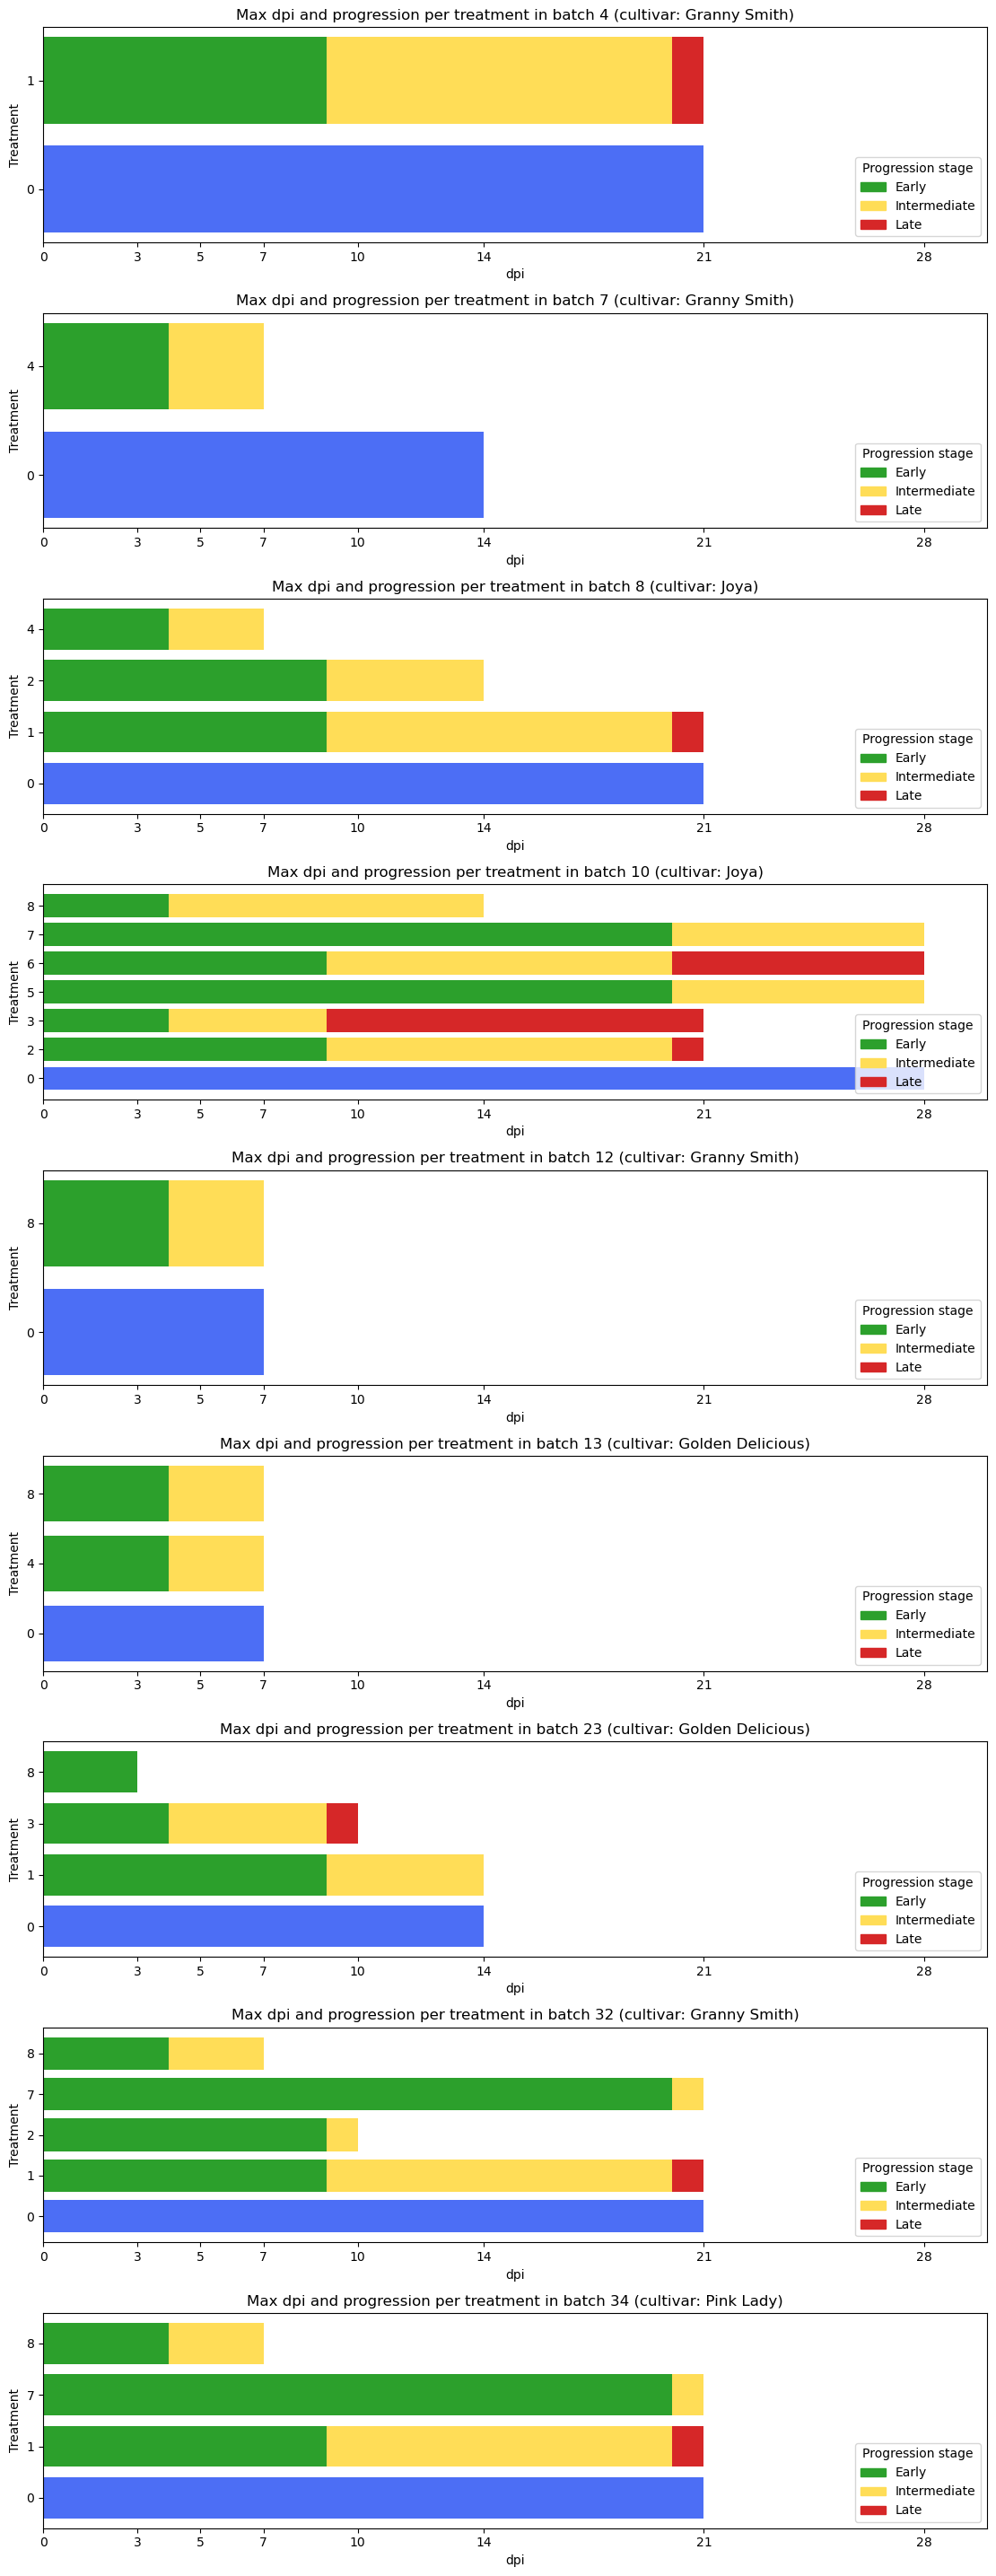

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from bisect import bisect_right


def plot_max_dpi_per_batch(progression_df: pd.DataFrame, show: bool = True):
    """Plot max dpi per treatment for each batch, split bars by progression stage, and show cultivar info."""
    if progression_df is None or progression_df.empty:
        print("No progression data to plot.")
        return None

    stage_colors = {
        "Early": "#2ca02c",
        "Intermediate": "#ffdd57",
        "Late": "#d62728",
    }

    possible_dpis = (
        progression_dates
        if "progression_dates" in globals()
        else sorted(progression_df["dpi"].dropna().unique())
    )
    possible_dpis = [int(d) for d in possible_dpis if pd.notna(d)]
    max_possible_dpi = max(possible_dpis) if possible_dpis else None

    def _stage_at_or_before(mapping: dict, d: int):
        """
        Forward-fill stage for dpi d using latest key <= d.
        IMPORTANT FIX: if d is before the first key, back-fill using the earliest stage
        so colored bars start at 0.
        """
        if not mapping:
            return None
        keys = sorted(int(k) for k in mapping.keys() if pd.notna(k))
        if not keys:
            return None

        # Back-fill before the first recorded dpi
        if d < keys[0]:
            return mapping[keys[0]]

        idx = bisect_right(keys, d) - 1
        return mapping[keys[idx]]

    def stage_blocks(treatment, max_dpi):
        """
        Build stage blocks from dpi=0.
        A stage recorded at dpi=d covers interval [d-1, d].
        And if the first stage is recorded at dpi=k, we back-fill it to cover [0, k].
        """
        mapping = (
            treatment_progressions.get(int(treatment))
            if "treatment_progressions" in globals()
            else {}
        )
        if not mapping or pd.isna(max_dpi):
            return []

        max_dpi = int(max_dpi)
        if max_dpi <= 0:
            return []

        # Intervals: [0,1], [1,2], ..., [max_dpi-1, max_dpi]
        right_edges = list(range(1, max_dpi + 1))  # 1..max_dpi
        stages = [_stage_at_or_before(mapping, d) for d in right_edges]

        if all(s is None for s in stages):
            return []

        blocks = []
        run_stage = stages[0]
        run_start_left = 0  # left edge in dpi units, starting at 0

        # i is interval index; interval i is [i, i+1]
        for i in range(1, len(right_edges)):
            if stages[i] != run_stage:
                if run_stage is not None:
                    blocks.append((run_start_left, i - run_start_left, run_stage))
                run_stage = stages[i]
                run_start_left = i

        # close last block
        if run_stage is not None:
            blocks.append((run_start_left, max_dpi - run_start_left, run_stage))

        return blocks

    # ---------- Build charts per batch ----------
    batch_charts = []
    for batch, grp in progression_df.groupby("batch", dropna=False):
        if pd.isna(batch):
            continue

        rows = []
        for treatment, t_grp in grp.groupby("treatment", dropna=False):
            t_sorted = t_grp.sort_values(["dpi", "progression"])
            if t_sorted.empty:
                continue
            last = t_sorted.iloc[-1]
            rows.append(
                {
                    "treatment": treatment,
                    "max_dpi": last["dpi"],
                }
            )

        if not rows:
            continue

        chart_df = (
            pd.DataFrame(rows)
            .sort_values("treatment")
            .reset_index(drop=True)
        )

        cultivars = (
            sorted(grp["cultivar"].dropna().unique())
            if "cultivar" in grp
            else []
        )
        batch_charts.append((batch, cultivars, chart_df))

    if not batch_charts:
        print("No plots created.")
        return None

    max_treatments = max(len(df) for _, _, df in batch_charts)
    fig, axes = plt.subplots(
        len(batch_charts),
        1,
        figsize=(max(8, 1.6 * max_treatments), 3.2 * len(batch_charts)),
    )

    if len(batch_charts) == 1:
        axes = [axes]

    legend_handles = [
        mpatches.Patch(color=color, label=stage)
        for stage, color in stage_colors.items()
    ]

    treatment_zero_color = "#4C6EF5"

    for ax, (batch, cultivars, chart_df) in zip(axes, batch_charts):
        ax.set_yticks(range(len(chart_df)))
        ax.set_yticklabels(chart_df["treatment"].astype(int))
        ax.set_ylabel("Treatment")
        ax.set_xlabel("dpi")

        cultivar_label = ", ".join(cultivars) if cultivars else "unknown"
        ax.set_title(
            f"Max dpi and progression per treatment in batch {int(batch)} "
            f"(cultivar: {cultivar_label})"
        )

        for idx, row in chart_df.iterrows():
            max_dpi = row["max_dpi"]
            if pd.isna(max_dpi):
                continue

            max_dpi_int = int(max_dpi)
            blocks = stage_blocks(row["treatment"], max_dpi_int)

            if blocks:
                for left, width, stage in blocks:
                    ax.barh(
                        idx,
                        width,
                        left=left,
                        color=stage_colors.get(stage, "#999999"),
                        edgecolor="none",
                    )
            else:
                color = (
                    treatment_zero_color
                    if int(row["treatment"]) == 0
                    else "#999999"
                )
                ax.barh(idx, max_dpi_int, left=0, color=color)

        ax.set_xticks(sorted({0} | set(possible_dpis)))
        if max_possible_dpi is not None:
            ax.set_xlim(0, max_possible_dpi + 2)

        ax.legend(
            handles=legend_handles,
            title="Progression stage",
            loc="lower right",
        )

    fig.tight_layout()
    if show:
        plt.show()
        return fig
    return fig


# Example usage:
progression_df = batch_treatment_progression(df_splitted)
fig = plot_max_dpi_per_batch(progression_df)
out_dir = Path("/mnt/slowdisk/public/HIPPA/multiclass_classification/results/cultivar_treatment_figures")
if fig is not None:
            fname = f"progression.png"
            fig.savefig(out_dir / fname, dpi=300, bbox_inches="tight")
            plt.close(fig)
# Batch 7, no treatment 2
# Batch 23, no treatment 7
# Batch 32, few apples from treatment 3 has to be removed
# Batch 34, no treatment 2


In [86]:
progression_df[(progression_df["batch"] == 34) & (progression_df["dpi"] == 28)]

,batch,cultivar,treatment,date,dpi,progression_stage,progression,samples
